In [ ]:
from pathlib import Path
import os

import os
os.chdir("/workspaces/group-project-team2/checkpoint/data_acquisition/")

import pandas as pd
import numpy as np

brfss1 = pd.read_parquet("BRFSS_2024_1.parquet.gzip")
brfss2 =  pd.read_parquet("BRFSS_2024_2.parquet.gzip")

In [53]:
brfss = pd.concat([brfss1, brfss2], axis = 0)

## Selecting Relevant Features

# Arakkal's

- **_EDUCAG (Education Level)**: Socioeconomic indicator that often correlates with health literacy, lifestyle choices, and health outcomes.

- **_INCOMG1 (Income Category)**: Socioeconomic variable affecting access to healthcare, healthy food options, and health-related resources.

- **_AGE_G (Age Group)**: Essential demographic variable that allows for age-stratified analysis and controls for age-related health patterns in outcome assessment.

- **_SEX (Sex)**: Key demographic predictor as health outcomes and risk factors often differ significantly between males and females.


# Lulu's

  
- **_BMI5 (Body Mass Index)**: Direct quantitative measure of body weight relative to height, crucial for assessing weight-related health risks.

- **_RFBMI5 (Obese)**: Binary obesity classification derived from BMI, serving as a primary outcome variable for identifying obesity prevalence and risk factors.

- **HTM4 (Height)**: Anthropometric measure needed for BMI calculations and body composition assessments.

- **_TOTINDA (Physical Activity)**: Important behavioral variable; physical activity is a known protective factor against obesity and chronic diseases.

- **WTKG3 (Weight)**: Direct weight measurement in kilograms, essential for BMI computation and weight status classification.

- **_RFSMOK3 (Smoking Status)**: Significant lifestyle factor that influences metabolism, weight patterns, and overall health outcomes.

- **_RFDRHV9 (Heavy Drinker)**: Behavioral risk factor; heavy alcohol consumption is associated with various health outcomes including weight gain.


In [54]:
cols = ["_AGE_G", "_SEX","_BMI5","_RFBMI5","HTM4", "_TOTINDA","WTKG3", "_RFSMOK3",
        "_RFDRHV9","_EDUCAG" , "_INCOMG1"]
data = brfss[cols]

In [55]:

# Renaming Variable Names

data = data.rename(columns={ "_SEX": "Sex",
                           "_BMI5": "BMI",
                           "_AGE_G": "Age_group",
                           "_RFBMI5": "Obese",
                           "HTM4": "Height(m)",
                           "_TOTINDA": "Physical_Activity",
                           "WTKG3": "Weight(kg)",
                           "_RFSMOK3": "Smoker",
                           "_RFDRHV9": "Heavy_Drinker",
                           "_EDUCAG": "Education_level",
                           "_INCOMG1": "Income_Cat"
                         })
data.columns

Index(['Age_group', 'Sex', 'BMI', 'Obese', 'Height(m)', 'Physical_Activity',
       'Weight(kg)', 'Smoker', 'Heavy_Drinker', 'Education_level',
       'Income_Cat'],
      dtype='object')

## Selecting Relevant Features

# Arakkal's

- **_EDUCAG (Education Level)**: Socioeconomic indicator that often correlates with health literacy, lifestyle choices, and health outcomes.

- **_INCOMG1 (Income Category)**: Socioeconomic variable affecting access to healthcare, healthy food options, and health-related resources.

- **_AGE_G (Age Group)**: Essential demographic variable that allows for age-stratified analysis and controls for age-related health patterns in outcome assessment.

- **_SEX (Sex)**: Key demographic predictor as health outcomes and risk factors often differ significantly between males and females.


# Lulu's

  
- **_BMI5 (Body Mass Index)**: Direct quantitative measure of body weight relative to height, crucial for assessing weight-related health risks.

- **_RFBMI5 (Obese)**: Binary obesity classification derived from BMI, serving as a primary outcome variable for identifying obesity prevalence and risk factors.

- **HTM4 (Height)**: Anthropometric measure needed for BMI calculations and body composition assessments.

- **_TOTINDA (Physical Activity)**: Important behavioral variable; physical activity is a known protective factor against obesity and chronic diseases.

- **WTKG3 (Weight)**: Direct weight measurement in kilograms, essential for BMI computation and weight status classification.

- **_RFSMOK3 (Smoking Status)**: Significant lifestyle factor that influences metabolism, weight patterns, and overall health outcomes.

- **_RFDRHV9 (Heavy Drinker)**: Behavioral risk factor; heavy alcohol consumption is associated with various health outcomes including weight gain.


In [56]:
cols = ["_AGE_G", "_SEX","_BMI5","_RFBMI5","HTM4", "_TOTINDA","WTKG3", "_RFSMOK3",
        "_RFDRHV9","_EDUCAG" , "_INCOMG1"]
data = brfss[cols]

## Renaming Variable Names 

In [57]:

# Renaming Variable Names

data = data.rename(columns={ "_SEX": "Sex",
                           "_BMI5": "BMI",
                           "_AGE_G": "Age_group",
                           "_RFBMI5": "Obese",
                           "HTM4": "Height(m)",
                           "_TOTINDA": "Physical_Activity",
                           "WTKG3": "Weight(kg)",
                           "_RFSMOK3": "Smoker",
                           "_RFDRHV9": "Heavy_Drinker",
                           "_EDUCAG": "Education_level",
                           "_INCOMG1": "Income_Cat"
                         })
data.columns

Index(['Age_group', 'Sex', 'BMI', 'Obese', 'Height(m)', 'Physical_Activity',
       'Weight(kg)', 'Smoker', 'Heavy_Drinker', 'Education_level',
       'Income_Cat'],
      dtype='object')

In [58]:
data.head()

,Age_group,Sex,BMI,Obese,Height(m),Physical_Activity,Weight(kg),Smoker,Heavy_Drinker,Education_level,Income_Cat
0,6.0,2.0,2249.0,1.0,163.0,1.0,5942.0,1.0,1.0,2.0,9.0
1,6.0,1.0,2583.0,2.0,178.0,1.0,8165.0,1.0,1.0,4.0,7.0
2,5.0,1.0,2253.0,1.0,198.0,1.0,8845.0,2.0,1.0,3.0,9.0
3,6.0,1.0,2509.0,2.0,173.0,1.0,7484.0,1.0,1.0,4.0,4.0
4,4.0,1.0,1977.0,1.0,173.0,2.0,5897.0,1.0,1.0,3.0,2.0


# Recoding Variables from Numeric to Categorical Format
- Converting Income Categories from Numeric Codes to Ordered Factor Labels:
 Preserves the natural hierarchy of income levels for appropriate statistical analysis.

- Transforming Education Level from Numeric Values to Ordered Categorical Variable:
 Captures the progressive nature of educational attainment from no diploma through college graduation.

- Recoding Heavy Drinker Status from Numeric to Categorical Format:
 Improves interpretability by using descriptive "Yes"/"No" labels for this binary variable.

- Converting Smoking Status from Numeric Codes to Binary Categories:
  Makes the data self-documenting and prevents numeric codes from being misinterpreted as quantitative.

- Mapping Physical Activity Variable from Numeric to Descriptive Categories:Provides clear, descriptive labels that eliminate ambiguity in understanding activity status.

- Transforming Age Group from Numeric Codes to Ordered Categorical Levels: Maintains the natural age progression for demographic analyses and stratification.

- Converting Sex Variable from Numeric to Character Labels: Eliminates the need for codebook reference by using immediately interpretable labels.

- Recoding Obesity Status from Numeric to Binary Categorical Format: Clearly communicates health status using straightforward "Yes"/"No" categories.

In [59]:

# Mapping Values In Categorical Variables ... Changing them From Numeric to Categories

# INCOME

# Converting  income var to integer
data["Income_Cat"] = data["Income_Cat"].astype("Int64")

# Ordered income categories
income_order = [
        "Less than $15,000",
        "$15,000 < $25,000",
        "$25,000 < $35,000",
        "$35,000 < $50,000",
        "$50,000 < $100,000",
        "$100,000 < $200,000",
        "$200,000 or more",
        "Missing/Don’t know",
]

# Replacing numeric codes with categories 
data["Income_Cat"] = pd.Categorical(
    data["Income_Cat"].map({
        1: "Less than $15,000",
        2: "$15,000 < $25,000",
        3: "$25,000 < $35,000",
        4: "$35,000 < $50,000",
        5: "$50,000 < $100,000",
        6: "$100,000 < $200,000",
        7: "$200,000 or more",
        9: np.nan
    }),
    categories = income_order,
    ordered = True
)

# EDUCATION

# Converting  education variable to integer 
data["Education_level"] = data["Education_level"].astype("Int64")

# Ordered education categories
education_order = [
    "Did not graduate High School",
    "Graduated High School",
    "Attended College or Technical School",
    "Graduated from College or Technical School",
    "Don’t know/Not sure/Missing"
]

# Replace numeric codes with categories and create an ordered categorical
data["Education_level"] = pd.Categorical(
    data["Education_level"].map({
        1: "Did not graduate High School",
        2: "Graduated High School",
        3: "Attended College or Technical School",
        4: "Graduated from College or Technical School",
        9: np.nan
    }),
    categories=education_order,
    ordered=True
)

# ALCOHOL

# Converting the column to integer
data["Heavy_Drinker"] = data["Heavy_Drinker"].astype("Int64")

# Map numeric codes 
data["Heavy_Drinker"] = pd.Categorical(
    data["Heavy_Drinker"].map({
        1: "No",
        2: "Yes",
        9: np.nan
    })
)

# SMOKING 

# Converting  column to integer 
data["Smoker"] = data["Smoker"].astype("Int64")

# Map numeric codes to categor
data["Smoker"] = pd.Categorical(
    data["Smoker"].map({
        1: "No",
        2: "Yes",
        9: np.nan 
    })
)

# OBESE

# Converting column to integer 
data["Obese"] = data["Obese"].astype("Int64")

# Mapping numeric codes to categories
data["Obese"] = data["Obese"].map({
    1: "No",
    2: "Yes",
    9: np.nan 
})

# SEX

# Converting to integer 
data["Sex"] = data["Sex"].astype("Int64")

# Mapping numeric codes to categories
data["Sex"] = data["Sex"].map({
    1: "Male",
    2: "Female"
})

# AGE GROUP

# Converting column to integer 
data["Age_group"] = data["Age_group"].astype("Int64")

# Defining the ordered categories
age_order = [
    "Age 18 to 24",
    "Age 25 to 34",
    "Age 35 to 44",
    "Age 45 to 54",
    "Age 55 to 64",
    "Age 65 or older"
]

# Map numeric codes to categories 
data["Age_group"] = pd.Categorical(
    data["Age_group"].map({
        1: "Age 18 to 24",
        2: "Age 25 to 34",
        3: "Age 35 to 44",
        4: "Age 45 to 54",
        5: "Age 55 to 64",
        6: "Age 65 or older"
    }),
    categories=age_order,
    ordered=True
)

# PHYSICAL ACTIVITY

# Converting column to integer 
data["Physical_Activity"] = data["Physical_Activity"].astype("Int64")

data["Physical_Activity"] = pd.Categorical(
    data["Physical_Activity"].map({
        1: "Had physical activity or exercise",
        2: "No physical activity or exercise in last 30 days",
        9: np.nan
    })
)

# Summary statistics and distributions  

In [60]:
data.describe(include = "category")

,Age_group,Physical_Activity,Smoker,Heavy_Drinker,Education_level,Income_Cat
count,457670,456355,425648,410972,455307,370247
unique,6,2,2,2,4,7
top,Age 65 or older,Had physical activity or exercise,No,No,Graduated from College or Technical School,"$50,000 < $100,000"
freq,172826,350061,378554,386812,191549,112409



Correlation (Heatmap) for numeric variables

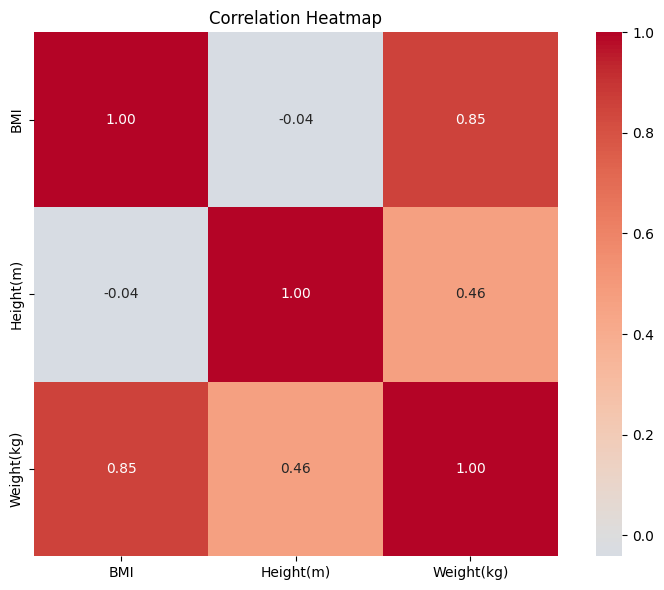

In [61]:
import seaborn as sns
import matplotlib.pyplot as plt

num_vars = data[['BMI', 'Height(m)', 'Weight(kg)']]

cor_matrix = num_vars.corr()

plt.figure(figsize=(8, 6))
sns.heatmap(cor_matrix, 
            annot=True, 
            fmt='.2f',
            cmap='coolwarm',
            center=0,
            square=True)
plt.title('Correlation Heatmap')
plt.tight_layout()
plt.show()

# Findings and Conclusion

The correlation analysis revealed a strong positive correlation between BMI and Weight (r = 0.85), indicating the presence of multicollinearity. Since BMI is mathematically derived from both height and weight, retaining all three variables simultaneously would introduce redundant information that could distort model estimates and inflate standard errors. Therefore, Height and Weight were excluded from the model, retaining only BMI as the anthropometric predictor, as it provides a clinically meaningful and non-redundant summary of both measures

# Data Preprocessing and Feature Engineering

In [62]:
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OrdinalEncoder, LabelEncoder, StandardScaler
from sklearn.impute import SimpleImputer, KNNImputer

#  Ordinal 
ordinal_cols_arakhal = ["Age_group", "Education_level", "Income_Cat"]
ordinal_orders_arakhal = [
    ["Age 18 to 24", "Age 25 to 34", "Age 35 to 44",
     "Age 45 to 54", "Age 55 to 64", "Age 65 or older"],
    ["Did not graduate High School", "Graduated High School",
     "Attended College or Technical School",
     "Graduated from College or Technical School",
     "Don't know/Not sure/Missing"],
    ["Less than $15,000", "$15,000 < $25,000", "$25,000 < $35,000",
     "$35,000 < $50,000", "$50,000 < $100,000",
     "$100,000 < $200,000", "$200,000 or more", "Missing/Don't know"],
]

# Ordinal pipeline with KNN imputation for arakhal
ordinal_pipeline = Pipeline(steps=[
    ("impute", SimpleImputer(strategy="most_frequent")),
    ("encode", OrdinalEncoder(
                   categories=ordinal_orders_arakhal,
                   handle_unknown="use_encoded_value",
                   unknown_value=np.nan
               )),
])


#  Binary 
binary_cols_arakhal = ["Sex"]
binary_cols_lulu   = ["Smoker", "Heavy_Drinker", "Physical_Activity"]
all_binary_cols    = binary_cols_arakhal + binary_cols_lulu

binary_pipeline = Pipeline([
    ('imputer', SimpleImputer(strategy='most_frequent')),  
    ('encoder', OrdinalEncoder())                         
])

# Numeric
numeric_cols_lulu = ["BMI"]

numeric_pipeline = Pipeline([
    ('imputer', SimpleImputer(strategy='mean')),   
    ('scaler', StandardScaler())                   
])

# Preprocessor
preprocessor = ColumnTransformer(
    transformers=[
    ('ordinal',  ordinal_pipeline,  ordinal_cols_arakhal),
    ('binary',   binary_pipeline,   all_binary_cols),
    ('numeric',  numeric_pipeline,  numeric_cols_lulu),
], remainder='drop')

#  Fit & Transform
X = data[ordinal_cols_arakhal + all_binary_cols + numeric_cols_lulu]
y = data['Obese']

X_processed = preprocessor.fit_transform(X)

# Converting Back to a Dataframe
feature_names = ordinal_cols_arakhal + all_binary_cols + numeric_cols_lulu
X_processed_data = pd.DataFrame(X_processed, columns=feature_names)

# dropping Missing values in the target variable , 43037 out of 457669 observations
mask = y.notna()
y = y[mask]
X_processed_data = X_processed_data[mask]

# Modelling

In [63]:
from sklearn.model_selection import cross_val_score
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, roc_auc_score
from imblearn.pipeline import Pipeline
from imblearn.over_sampling import SMOTE

def run_classifier(classifier):
    X_train, X_test, y_train, y_test = train_test_split(
        X_processed_data, y,
        test_size=0.2,
        random_state=42,
        stratify=y
    )

    # Applying SMOTE since the target variable is imbalanced
    pipeline = Pipeline([
        ("smote",      SMOTE(random_state=42)),
        ("classifier", classifier)
    ])

    # 5-fold CV
    cv_scores = cross_val_score(pipeline, X_train, y_train, scoring="f1_macro", cv=5)
    print(f"\n{classifier.__class__.__name__}")
    print(f"CV F1 scores : {cv_scores.round(4)}")
    print(f"Mean F1      : {cv_scores.mean():.4f} (+/- {cv_scores.std():.4f})")

    # Model Evaluation
    pipeline.fit(X_train, y_train)
    y_pred  = pipeline.predict(X_test)
    y_proba = pipeline.predict_proba(X_test)[:, 1]

    print(f"\n{classification_report(y_test, y_pred, target_names=['Not Obese', 'Obese'])}")
    print(f"ROC-AUC: {roc_auc_score(y_test, y_proba):.4f}")

    return cv_scores

In [64]:
# Logistic Regression
run_classifier(LogisticRegression(max_iter=1000, random_state=42))


LogisticRegression
CV F1 scores : [0.9945 0.9951 0.9942 0.9951 0.9952]
Mean F1      : 0.9948 (+/- 0.0004)

              precision    recall  f1-score   support

   Not Obese       0.99      1.00      0.99     25686
       Obese       1.00      1.00      1.00     57241

    accuracy                           1.00     82927
   macro avg       1.00      1.00      1.00     82927
weighted avg       1.00      1.00      1.00     82927

ROC-AUC: 1.0000


array([0.99450984, 0.99505286, 0.99422718, 0.99512563, 0.99517925])

# Findings
- Scores are suspiciously perfect

In [65]:
# Checking a variable that is highly correlated with the target that may cause tis perfectness
y_numeric = (y == 'Yes').astype(int)
print(X_processed_data.corrwith(y_numeric).sort_values(ascending=False))

# BMI ~ 0.646697

BMI                  0.646697
Sex                  0.092058
Physical_Activity    0.073012
Age_group            0.058163
Income_Cat          -0.009903
Heavy_Drinker       -0.017411
Smoker              -0.034617
Education_level     -0.044365
dtype: float64


In [66]:
#  Random Forest
run_classifier(RandomForestClassifier(n_estimators=100, random_state=42))


RandomForestClassifier
CV F1 scores : [1. 1. 1. 1. 1.]
Mean F1      : 1.0000 (+/- 0.0000)

              precision    recall  f1-score   support

   Not Obese       1.00      1.00      1.00     25686
       Obese       1.00      1.00      1.00     57241

    accuracy                           1.00     82927
   macro avg       1.00      1.00      1.00     82927
weighted avg       1.00      1.00      1.00     82927

ROC-AUC: 1.0000


array([1., 1., 1., 1., 1.])

In [67]:
# BMI is dropped due to data leakage (0.65 correlation with target)
# It directly defines obesity clinically (BMI >= 30 = obese)

X_processed_no_bmi = X_processed_data.drop(columns=["BMI"])
X_processed_data = X_processed_no_bmi

# Retraining without BMI
run_classifier(LogisticRegression(max_iter=1000, random_state=42))
run_classifier(RandomForestClassifier(n_estimators=100, random_state=42))


LogisticRegression
CV F1 scores : [0.5552 0.5528 0.5547 0.5525 0.5534]
Mean F1      : 0.5537 (+/- 0.0010)

              precision    recall  f1-score   support

   Not Obese       0.38      0.59      0.46     25686
       Obese       0.76      0.57      0.65     57241

    accuracy                           0.58     82927
   macro avg       0.57      0.58      0.56     82927
weighted avg       0.64      0.58      0.59     82927

ROC-AUC: 0.5943

RandomForestClassifier
CV F1 scores : [0.5859 0.5832 0.5784 0.5854 0.584 ]
Mean F1      : 0.5834 (+/- 0.0027)

              precision    recall  f1-score   support

   Not Obese       0.41      0.56      0.48     25686
       Obese       0.77      0.64      0.70     57241

    accuracy                           0.62     82927
   macro avg       0.59      0.60      0.59     82927
weighted avg       0.66      0.62      0.63     82927

ROC-AUC: 0.6380


array([0.58591058, 0.58324433, 0.57844294, 0.58535756, 0.58404455])

# Feature importance